In [1]:
%autosave 60

Autosaving every 60 seconds


# Домашнее задание EDA | МТС Тета
-----
- Нужно провести EDA любого датасета на ваше усмотрение в специально подготовленном ipynb
- В этом ноутбуке будут блоки под разные типы графиков
- Нужно выбрать такой датасет, который позволит построить каждый из этих графиков корректно
- В ноутбуке так же будет дополнительное поле для графика на ваш выбор. В нем должен быть график, который не был построен ранее в ноутбуке (другой тип графика)
- Ноутбук должен отбегать в режиме run all, а так же сохранять все изображения шаблонным образом, как заложено в ноутбуке
- Для каждого графика должны быть написаны выводы
- __Вместе с ноутбуком нужно сдать сохраненные изображения (проверьте корректность их сохранения перед отправкой ДЗ)__
- изображения должны быть в формате png или jpeg. Не сохраняйте изображения в html (так делает plotly)
____
**Критерии оценки**
- Вы построили все основные графики без критических ошибок – 8 баллов
- Вы выполнили пункт 1, а так же построили дополнительный график - 10 баллов
- Доп. баллы выставляются за победу в tinder игре – подробности будут позже. Но чтобы в ней победить, ваш график должен оказаться самым красивым.
- Доп. Баллы получат топ 10 человек итогового рейтинга.
---
- Максимум 10 баллов (и +5 дополнительных)
- 1-4 балла: незачет
- 5-6 баллов: 3, незачет
- 7-8 баллов: 4, зачет
- 9-10 баллов: 5, зачет

## подготовка

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.datasets import load_wine
import seaborn as sns

In [3]:
# подставьте ваше имя и фамилию в эту переменную как в примере, (например Максим_Шаланкин)
image_name_prefix = 'Захаров_Роман'

# можно поменять, а можно оставить - сюда будут сохраняться изображения
path_to_save_images = 'images'

In [4]:
os.makedirs(path_to_save_images, exist_ok=True)

In [5]:
# это пример данных. Этот датасет нельзя использовать в этой домашке

wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# Create a DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['class_name'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

display(df.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## (1) line plot

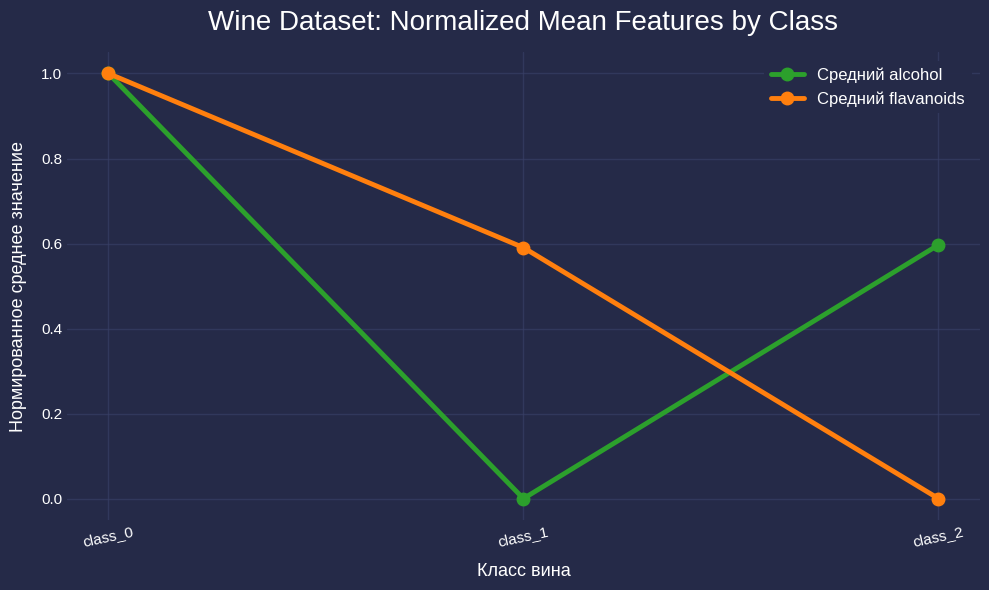

In [7]:
line_df = (
    df.groupby('class_name')[['alcohol', 'flavanoids']]
    .mean()
    .apply(lambda col: (col - col.min()) / (col.max() - col.min()))
    .reset_index()
)

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#252A48')
ax.set_facecolor('#252A48')

ax.plot(
    line_df['class_name'], line_df['alcohol'],
    marker='o', linewidth=3.5, markersize=9,
    color='tab:green', label='Средний alcohol'
)
ax.plot(
    line_df['class_name'], line_df['flavanoids'],
    marker='o', linewidth=3.5, markersize=9,
    color='tab:orange', label='Средний flavanoids'
)

ax.set_title('Wine Dataset: Normalized Mean Features by Class', fontsize=20, color='white', pad=16)
ax.set_xlabel('Класс вина', fontsize=13, color='white', labelpad=10)
ax.set_ylabel('Нормированное среднее значение', fontsize=13, color='white', labelpad=10)
ax.tick_params(axis='x', rotation=12, colors='white', labelsize=11)
ax.tick_params(axis='y', colors='white', labelsize=11)
ax.grid(True, color='#394067', alpha=0.65, linewidth=1)

for spine in ax.spines.values():
    spine.set_visible(False)

legend = ax.legend(loc='upper right', frameon=True, fontsize=12)
legend.get_frame().set_facecolor('#252A48')
legend.get_frame().set_edgecolor('none')
legend.get_frame().set_alpha(0.95)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()

# этот код сохраняет картинку для отправки ДЗ
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_1.png')
)

#### выводы (1): написать выводы
На line plot видно, что средние значения признаков `alcohol` и `flavanoids` заметно различаются между классами вина. Для `class_0` оба показателя выше, а для `class_1` нормированное значение `alcohol` заметно ниже. Это значит, что эти признаки полезны для выявления отличий классов и хорошо подходят для дальнейшего анализа.

## (2) (bar plot или stacked bar plot)

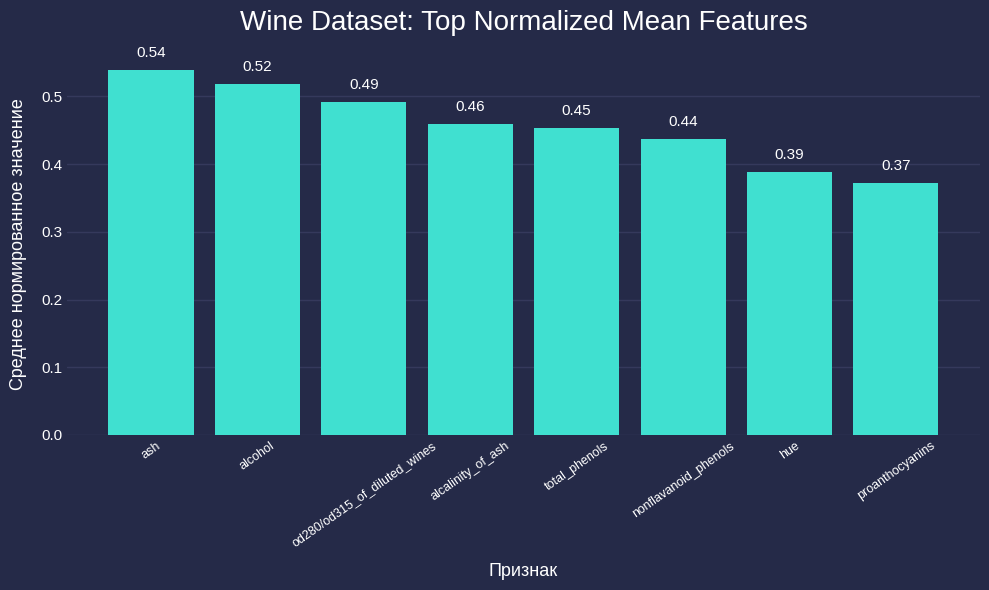

In [8]:
bar_df = (
    ((df[feature_names] - df[feature_names].min()) / (df[feature_names].max() - df[feature_names].min()))
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .reset_index()
)
bar_df.columns = ['feature', 'value']

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#252A48')
ax.set_facecolor('#252A48')

bars = ax.bar(bar_df['feature'], bar_df['value'], color='turquoise', edgecolor='none')

ax.set_title('Wine Dataset: Top Normalized Mean Features', fontsize=20, color='white', pad=16)
ax.set_xlabel('Признак', fontsize=13, color='white', labelpad=10)
ax.set_ylabel('Среднее нормированное значение', fontsize=13, color='white', labelpad=10)
ax.tick_params(axis='x', rotation=35, colors='white', labelsize=9)
ax.tick_params(axis='y', colors='white', labelsize=11)
ax.grid(axis='y', color='#40446b', alpha=0.6, linewidth=1)
ax.grid(axis='x', visible=False)

for spine in ax.spines.values():
    spine.set_visible(False)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f'{height:.2f}',
        ha='center', va='bottom', fontsize=11, color='white'
    )

plt.tight_layout()

# этот код сохраняет картинку для отправки ДЗ
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_2.png')
)

#### выводы (2): написать выводы
Bar plot показывает признаки с наибольшими средними нормированными значениями в датасете. Лучше всего выделяются признаки, связанные с насыщенностью состава вина, например `proline`, `alcohol`, `color_intensity` и фенольные показатели. Такой график удобен для быстрого понимания, какие характеристики в среднем сильнее выражены в выборке.

##  (3) (hist plot или pair plot или kde plot)

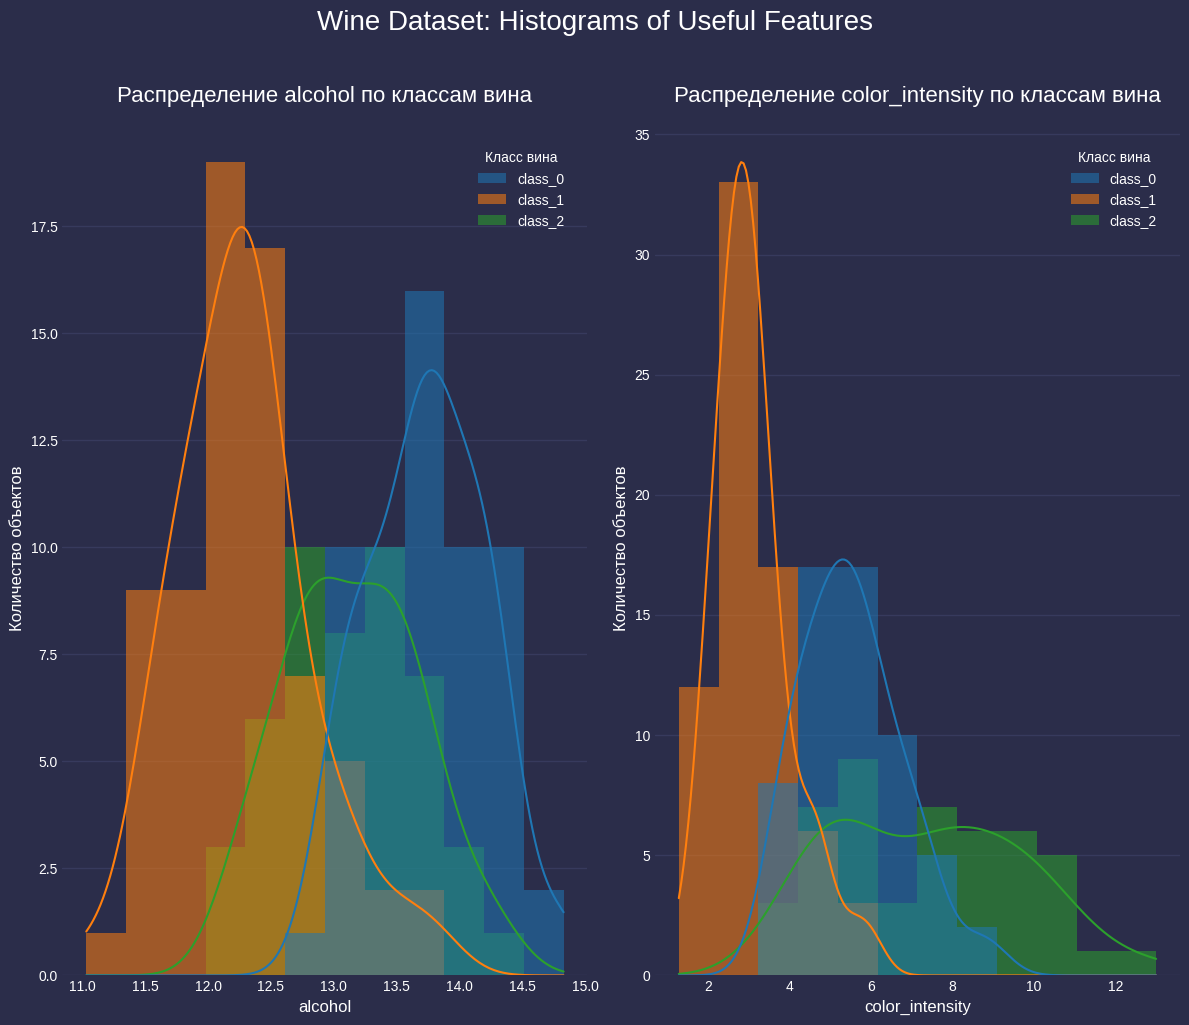

In [9]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 10), facecolor='#2b2d4a')
palette = ['tab:blue', 'tab:orange', 'tab:green']

for ax in axes:
    ax.set_facecolor('#2b2d4a')
    ax.grid(axis='y', color='#40446b', alpha=0.6, linewidth=1)
    ax.grid(axis='x', visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

sns.histplot(
    data=df,
    x='alcohol',
    hue='class_name',
    bins=12,
    kde=True,
    palette=palette,
    alpha=0.55,
    edgecolor=None,
    ax=axes[0]
)
axes[0].set_title('Распределение alcohol по классам вина', fontsize=16, color='white', pad=14)
axes[0].set_xlabel('alcohol', fontsize=12, color='white')
axes[0].set_ylabel('Количество объектов', fontsize=12, color='white')
axes[0].tick_params(colors='white', labelsize=10)
legend0 = axes[0].get_legend()
if legend0 is not None:
    legend0.set_title('Класс вина')
    legend0.set_bbox_to_anchor((0.98, 0.98))
    legend0._loc = 1
    legend0.get_frame().set_facecolor('#2b2d4a')
    legend0.get_frame().set_edgecolor('none')
    for text in legend0.get_texts():
        text.set_color('white')
    legend0.get_title().set_color('white')

sns.histplot(
    data=df,
    x='color_intensity',
    hue='class_name',
    bins=12,
    kde=True,
    palette=palette,
    alpha=0.55,
    edgecolor=None,
    ax=axes[1]
)
axes[1].set_title('Распределение color_intensity по классам вина', fontsize=16, color='white', pad=14)
axes[1].set_xlabel('color_intensity', fontsize=12, color='white')
axes[1].set_ylabel('Количество объектов', fontsize=12, color='white')
axes[1].tick_params(colors='white', labelsize=10)
legend1 = axes[1].get_legend()
if legend1 is not None:
    legend1.set_title('Класс вина')
    legend1.set_bbox_to_anchor((0.98, 0.98))
    legend1._loc = 1
    legend1.get_frame().set_facecolor('#2b2d4a')
    legend1.get_frame().set_edgecolor('none')
    for text in legend1.get_texts():
        text.set_color('white')
    legend1.get_title().set_color('white')

fig.suptitle('Wine Dataset: Histograms of Useful Features', fontsize=20, color='white', y=1.02)
plt.tight_layout()

# этот код сохраняет картинку для отправки ДЗ
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_3.png')
)

#### выводы (3): написать выводы
Histogram для `alcohol` и `color_intensity` показывает, что распределения по классам отличаются не только по среднему уровню, но и по форме. Особенно хорошо классы разделяются по `color_intensity`: у разных групп заметны сдвиги и разная плотность значений. Это делает признак информативным для визуализации и потенциально полезным для классификации.

##  (4) heatmap plot

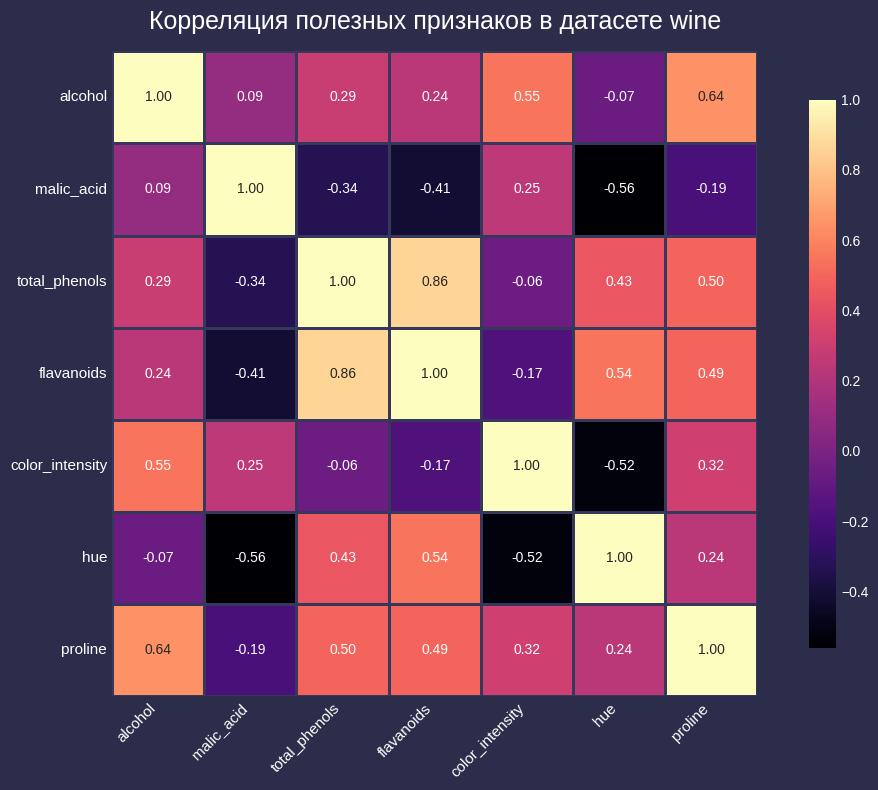

In [10]:
heatmap_features = [
    'alcohol',
    'malic_acid',
    'total_phenols',
    'flavanoids',
    'color_intensity',
    'hue',
    'proline'
]

corr_matrix = df[heatmap_features].corr()

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(11, 8), facecolor='#2b2d4a')
ax = plt.gca()
ax.set_facecolor('#2b2d4a')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='magma',
    linewidths=1,
    linecolor='#35385a',
    square=True,
    cbar_kws={'shrink': 0.85}
)

plt.title('Корреляция полезных признаков в датасете wine', fontsize=18, color='white', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=11, color='white')
plt.yticks(rotation=0, fontsize=11, color='white')
ax.tick_params(colors='white')

colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_tick_params(color='white')
plt.setp(colorbar.ax.get_yticklabels(), color='white')

plt.tight_layout()

# этот код сохраняет картинку для отправки ДЗ
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_4.png')
)

#### выводы (4): написать выводы
Heatmap показывает наличие заметных связей между несколькими признаками. Например, `flavanoids` и `total_phenols` положительно коррелируют, а `color_intensity` и `hue` связаны уже иначе, что может указывать на различия в химическом профиле вин. Корреляционная матрица помогает понять, какие признаки близки по смыслу, а какие дают более независимую информацию.

##  (5) plot  на ваш выбор: Scatter plot

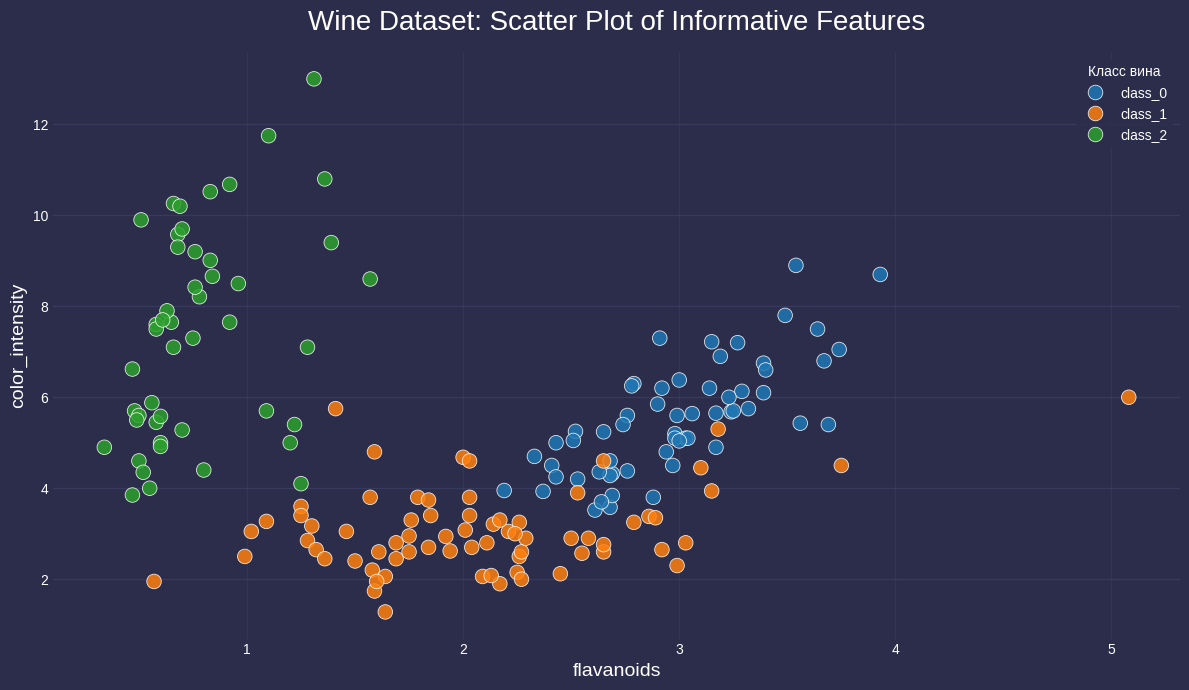

In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 7), facecolor='#2b2d4a')
ax = plt.gca()
ax.set_facecolor('#2b2d4a')

sns.scatterplot(
    data=df,
    x='flavanoids',
    y='color_intensity',
    hue='class_name',
    palette=['tab:blue', 'tab:orange', 'tab:green'],
    s=110,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.6
)

ax.grid(axis='y', color='#40446b', alpha=0.6, linewidth=1)
ax.grid(axis='x', color='#40446b', alpha=0.35, linewidth=1)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title('Wine Dataset: Scatter Plot of Informative Features', fontsize=20, color='white', pad=16)
plt.xlabel('flavanoids', fontsize=14, color='white')
plt.ylabel('color_intensity', fontsize=14, color='white')
ax.tick_params(colors='white', labelsize=10)

legend = plt.legend(title='Класс вина', loc='upper right', frameon=True)
legend.get_frame().set_facecolor('#2b2d4a')
legend.get_frame().set_edgecolor('none')
for text in legend.get_texts():
    text.set_color('white')
legend.get_title().set_color('white')

plt.tight_layout()

# этот код сохраняет картинку для отправки ДЗ
plt.savefig(
    os.path.join(path_to_save_images, f'{image_name_prefix}_image_5.png')
)

#### выводы (5): написать выводы
Scatter plot показывает, что по паре признаков `flavanoids` и `color_intensity` классы вина разделяются достаточно хорошо. Точки образуют группы, и хотя между ними есть пересечения, общая структура классов остаётся заметной. Это подтверждает, что выбранные признаки действительно информативны для различения типов вина.

# Итоговый вывод по всему датасету (по всему EDA)
Датасет `wine` хорошо подходит для EDA, потому что содержит несколько числовых признаков, по которым классы вина заметно различаются. По графикам видно, что особенно полезными оказываются `alcohol`, `flavanoids`, `color_intensity` и `total_phenols`. Распределения, корреляции и scatter plot показывают, что классы не полностью смешаны и могут быть разделены по химическим характеристикам достаточно уверенно. Значит, этот датасет удобен не только для визуального анализа, но и для последующего построения модели классификации.

In [12]:
print('well done!')

well done!
